## 1. What this notebook computes

Notebooks 03a and 03b described the author's metric and its curvature. This notebook
asks what the metric DOES: how does a small body move when no force acts on it, only
the geometry? Such a body is in **free fall**, and its path is a **geodesic**. The
notebook

- reads the 25 non-zero Christoffel symbols of the Revision record
  `Revision/gkd_lovelock/results/curvature.json` and builds from them the geodesic
  equations, 16 first-order equations for the 8 coordinates and the 8 velocities;
- proves exactly, with sympy, what stays constant during free fall: the six
  **momenta** along $x_1, x_2, x_3$ and $x_5, x_6, x_7$ and the squared length of the
  velocity;
- proves that the velocity of a body moving in 3-space, measured with rulers and
  clocks at its place, falls like $e^{-a_4}$ at a fixed height in the hidden
  direction (**redshift**: 3-space inflates), while its velocity along an extra time
  grows like $e^{a_4}$ (**blueshift**: the extra times deflate), and reproduces the
  **momentum weight** $\kappa = e^{-Hy - a_4}$ of the Revision Kohn-Sham record;
- proves that motion in 3-space pushes the body towards the patch end of the hidden
  direction, motion along an extra time towards the tip, and that the velocity
  along the time $x_4$ can only decrease;
- shows that the squared $x_4$ velocity of the body is the same quadratic form as the
  squared frequency of a plane wave in the Revision record's check
  `extra_time_growth_rates_unbounded`;
- integrates the geodesic equations numerically (RK4) for a body at rest, three
  bodies moving in 3-space and one body moving along an extra time, along the
  deflating history $a_4 = AHx_4$ ($A = 1$, $H = 1$), checks every exact law on the
  computed paths, finds the instant at which the last body stops advancing in $x_4$,
  and measures the accuracy of RK4;
- draws 5 figures and prints a PASS line for every check.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 03d (Free fall in the author's metric: conserved momenta, redshift, blueshift
and the push along the hidden direction) is the file
`Revision/textbook/notebooks/03d_free_fall.ipynb` of the repository Dirac_claude. It
integrates the geodesic equations of free fall in the author's metric with the
Christoffel symbols of the Revision record, along the deflating history a4 = A H x4 with
A = 1 and H = 1, by the Runge-Kutta method RK4. With sympy it proves exactly that the six
momenta along x1, x2, x3, x5, x6, x7 and the squared length of the velocity are
conserved, that the frame velocity in 3-space falls like e^(-a4) (redshift) while the
frame velocity along an extra time grows like e^(a4) (blueshift), that the hidden
coordinate y is pushed with the acceleration H times the difference of the squared
3-space and extra-time frame velocities, and that the x4 velocity can only decrease; it
reproduces the momentum weight of the Revision Kohn-Sham record and the quadratic form of
the plane-wave check of the Revision scope report. It checks all of this on the computed
paths, finds the turning point in x4 of a particle that moves along an extra time,
measures the order 4 of RK4, and draws 5 figures. It needs a computer with Windows 11,
macOS or Linux, an internet connection for the installation, the program Git, and Python
3.12 or newer (the notebooks were built with Python 3.14.5) with these packages at
exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0,
jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert
7.16.6. The notebook itself imports numpy, sympy and matplotlib; the other packages run
Jupyter, the program that shows and runs notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 03d_free_fall.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 50 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 03d_free_fall.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
03d_free_fall.ipynb` (in the same folder, without running the cells again) to read the
printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/03d.captions.json`
- `Revision/textbook/figures/03d_1_frame_velocities.png`
- `Revision/textbook/figures/03d_2_x4_velocity.png`
- `Revision/textbook/figures/03d_3_hidden_push.png`
- `Revision/textbook/figures/03d_4_quadratic_form.png`
- `Revision/textbook/figures/03d_5_accuracy.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS all five figure files exist
    ALL 23 CHECKS PASSED (notebook 03d)

and the notebook must show 5 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/03d_free_fall.ipynb` inside the folder Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "FileNotFoundError" for curvature.json, parameters.json, ks-theory.json or
  python-scope.json: the notebook reads these four Revision records of the repository, so
  the folder Revision of your copy is incomplete. Restore it with the following command
  in the repository folder (or clone the repository again) and run the notebook again:

      git checkout -- Revision

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 03d (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 03d (Free fall in the author's metric: conserved momenta, redshift, blueshift
# and the push along the hidden direction) is the file
# Revision/textbook/notebooks/03d_free_fall.ipynb of the repository Dirac_claude. It
# integrates the geodesic equations of free fall in the author's metric with the
# Christoffel symbols of the Revision record, along the deflating history a4 = A H x4
# with A = 1 and H = 1, by the Runge-Kutta method RK4. With sympy it proves exactly that
# the six momenta along x1, x2, x3, x5, x6, x7 and the squared length of the velocity are
# conserved, that the frame velocity in 3-space falls like e^(-a4) (redshift) while the
# frame velocity along an extra time grows like e^(a4) (blueshift), that the hidden
# coordinate y is pushed with the acceleration H times the difference of the squared
# 3-space and extra-time frame velocities, and that the x4 velocity can only decrease; it
# reproduces the momentum weight of the Revision Kohn-Sham record and the quadratic form
# of the plane-wave check of the Revision scope report. It checks all of this on the
# computed paths, finds the turning point in x4 of a particle that moves along an extra
# time, measures the order 4 of RK4, and draws 5 figures. It needs a computer with
# Windows 11, macOS or Linux, an internet connection for the installation, the program
# Git, and Python 3.12 or newer (the notebooks were built with Python 3.14.5) with these
# packages at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib
# 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and
# nbconvert 7.16.6. The notebook itself imports numpy, sympy and matplotlib; the other
# packages run Jupyter, the program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 03d_free_fall.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 50
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 03d_free_fall.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 03d_free_fall.ipynb (in the same folder, without running the cells again) to read the
# printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/03d.captions.json
# - Revision/textbook/figures/03d_1_frame_velocities.png
# - Revision/textbook/figures/03d_2_x4_velocity.png
# - Revision/textbook/figures/03d_3_hidden_push.png
# - Revision/textbook/figures/03d_4_quadratic_form.png
# - Revision/textbook/figures/03d_5_accuracy.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS all five figure files exist
#     ALL 23 CHECKS PASSED (notebook 03d)
#
# and the notebook must show 5 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/03d_free_fall.ipynb inside the folder Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "FileNotFoundError" for curvature.json, parameters.json, ks-theory.json or
#   python-scope.json: the notebook reads these four Revision records of the repository,
#   so the folder Revision of your copy is incomplete. Restore it with the following
#   command in the repository folder (or clone the repository again) and run the notebook
#   again:
#     git checkout -- Revision
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "03d"  # this notebook: chapter 03, example d


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 03d complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Coordinates** $x_1, \dots, x_8$ (the author's names): $x_1, x_2, x_3$ ordinary
  3-space, $x_4$ the time, $x_5, x_6, x_7$ the three **extra times**, $x_8$ the
  **hidden** direction; $z = 6Hx_8$ with $0 < z < \pi/2$. In Python lists they are
  counted 0 to 7.
- **Hidden coordinate** $y = \ln(\sin z)/(6H)$: the proper distance along the
  hidden direction, $y = 0$ at the **patch end** $z = \pi/2$ and $y \to -\infty$ at
  the **tip** $z \to 0$.
- **Free fall**: motion under no force other than the geometry. **Test particle**: a
  body so small that it does not change the metric.
- **Proper time** $\tau$: the time shown by a clock carried by the body.
- **Velocity** $u^a = dx^a/d\tau$: how fast each coordinate changes per unit of
  proper time.
- **Geodesic equation**: $du^a/d\tau = -\sum_{b,c} \Gamma^a{}_{bc}\, u^b u^c$, with
  the Christoffel symbols $\Gamma^a{}_{bc}$ of the metric; its solutions are the
  paths of free fall.
- **Squared length of the velocity**: $g(u, u) = \sum_a g_{aa} (u^a)^2$ (the metric
  is diagonal). For a body with mass it equals $-1$ when $\tau$ is its proper time.
- **Scale factor** $h_a = \sqrt{|g_{aa}|}$ and **frame velocity**
  $\hat u^a = h_a u^a$: the proper length (along an extra time: the proper
  duration) that the body covers along $x_a$ per unit of its own proper time,
  measured with the rulers and clocks of an observer at rest at its place; divided
  by $u^4$ it is the velocity that this observer measures.
- **Momentum** $p_a = g_{aa} u^a$ (no sum) of a direction $x_a$. **Conserved**: the
  same number at every point of the path.
- **Redshift, blueshift**: the decrease, increase of a frame velocity (or momentum)
  caused by the expansion, contraction of the space it points along.
- **History** $a_4 = AHx_4$: the time dependence of the metric used for the numbers,
  the one of the Revision Kohn-Sham work ($A = 1$, $H = 1$); with $A > 0$ the extra
  times deflate. It is a **prescribed background**: assumed, not solved for.
- **RK4**: the classical Runge-Kutta method of order 4; halving its step makes its
  error about $2^4 = 16$ times smaller.
- **Turning point**: the instant at which the $x_4$ velocity $u^4$ passes through
  zero, so that $x_4$ stops growing.

## 4. The physical and mathematical situation

The author's metric is diagonal,
$g = \mathrm{diag}(h_1^2, h_2^2, h_3^2, -1, -h_5^2, -h_6^2, -h_7^2, h_8^2)$ with
the scale factors $h_1 = h_2 = h_3 = e^{a_4}\sin^{1/6}z$ (3-space, inflating),
$h_5 = h_6 = h_7 = e^{-a_4}\sin^{1/6}z$ (the extra times, deflating) and
$h_8 = \cot z$. A test particle with mass falls freely along a solution of the
**geodesic equations**

$$\frac{dx^a}{d\tau} = u^a, \qquad \frac{du^a}{d\tau} = -\sum_{b,c}
\Gamma^a{}_{bc}\, u^b u^c \qquad (a = 1, \dots, 8),$$

sixteen first-order equations. The Christoffel symbols are those of the Revision
record (Notebook 03b checked them component by component). The metric depends only
on $x_4$ and $x_8$; for each of the other six directions this makes a momentum
$p_a = g_{aa} u^a$ conserved (section 6). The squared length $g(u, u)$ of the
velocity is conserved too, and we choose it equal to $-1$: then $\tau$ is the
proper time of the particle and the path is time-like.

For the numbers the notebook uses the deflating history $a_4 = AHx_4$ of the
Revision Kohn-Sham work with $A = 1$ and $H = 1$ (so $a_4' = 1$). It is a
prescribed background, and the particles are test particles: they move in the given
metric and do not change it. Everything in sections 6 to 9 holds for a general
function $a_4(x_4)$; only the numerical paths of sections 10 to 12 use the history.

## 5. The Christoffel symbols, read from the record

First a technical step. While a cell runs, Jupyter sends what the cell prints to the
notebook in pieces, about one piece every 0.2 seconds, so where one piece ends and
the next begins depends on the speed of the computer. The tools that build this
book read the PASS line of a check together with the line under it that names the
Revision record, and they read the two correctly only when both arrive in the same
piece. The next cell therefore defines the function `in_one_piece(helper)`: it
returns a new function that does exactly what `helper` does, but lets `helper`
print into a text buffer in memory (an `io.StringIO`, with
`contextlib.redirect_stdout`) and then writes the whole buffer with one call of
`sys.stdout.write`, which arrives as one piece. (The stars in `*arguments` and
`**options` pass on all the values the new function is given, whatever they are.)
The cell then replaces the helpers `check` and `report` of the set-up cell by such
functions. Nothing else changes: the same checks, the same PASS lines, the same
numbers.

In [2]:
import contextlib  # redirect_stdout: send printed text into a buffer
import io  # StringIO: a text buffer in memory
import sys  # sys.stdout: the place where printed text goes


def in_one_piece(helper):
    """A function that does what helper does, with all the lines that helper prints
    written in one piece."""
    def helper_in_one_piece(*arguments, **options):
        collected = io.StringIO()  # an empty text buffer
        with contextlib.redirect_stdout(collected):  # print() writes into it
            helper(*arguments, **options)  # a failing check stops here, as before
        sys.stdout.write(collected.getvalue())  # all the lines with one write
    return helper_in_one_piece


check = in_one_piece(check)  # a PASS line and its record line stay together
report = in_one_piece(report)  # a long RESULT line and its second line, too
say("From now on check and report print each of their results in one piece.")

From now on check and report print each of their results in one piece.


The next cell imports the packages, makes the symbols (the eight coordinates, the
constant $H > 0$, the function $a_4(x_4)$, and the printing names `a4p` for $a_4'$
and `a4v` for the value of $a_4$), and reads the list `christoffelNonzero_b_le_c` of
the record. Each entry gives the three indices `a`, `b`, `c` of
$\Gamma^a{}_{bc}$ (with $b \le c$) and its value in Mathematica notation, which the
function `from_mathematica` translates into sympy (the same translation as in
Notebook 03b: `Derivative[1][a4][x4]` becomes `a4p`, `a4[x4]` becomes `a4v`, square
brackets of functions become round ones, `^` becomes `**`). Because
$\Gamma^a{}_{bc} = \Gamma^a{}_{cb}$, every entry with $b < c$ is stored twice, once
for each order of the lower indices: the 25 entries give 37 symbols. The cell prints
four of them.

In [3]:
import numpy as np  # arrays of numbers
import sympy as sp  # exact algebra with symbols
from sympy.parsing.sympy_parser import parse_expr  # text -> sympy expression

CURVATURE_RECORD = "Revision/gkd_lovelock/results/curvature.json"
record = json.loads(repository_file(CURVATURE_RECORD).read_text(encoding="utf-8"))
NAMES = ["x1", "x2", "x3", "x4", "x5", "x6", "x7", "x8"]
X = sp.symbols("x1:9", real=True)  # the coordinates x1 ... x8 (X[0] ... X[7])
x4, x8 = X[3], X[7]
H = sp.symbols("H", positive=True)  # the constant of the author
a4 = sp.Function("a4")(x4)  # the metric function, any function of x4
a4p, a4v = sp.symbols("a4p a4v", real=True)  # printing names: a4 prime, a4
record_names = {"a4p": a4p, "a4v": a4v, "H": H, "x8": x8, "E": sp.E,
                "sin": sp.sin, "cot": sp.cot}


def from_mathematica(entry_text):
    """A value of the record (Mathematica notation) as a sympy expression."""
    t = entry_text.replace("Derivative[1][a4][x4]", "a4p").replace("a4[x4]", "a4v")
    t = t.replace("Sin[6*H*x8]", "sin(6*H*x8)").replace("Cot[6*H*x8]", "cot(6*H*x8)")
    t = t.replace("^", "**")
    if "[" in t or "]" in t:  # a piece of notation that was not translated
        raise ValueError(f"cannot translate {entry_text}")
    return parse_expr(t, local_dict=record_names)


Gamma = {}  # (a, b, c) -> the value of Gamma^a_bc, with a4p and a4v
for entry in record["christoffelNonzero_b_le_c"]:
    a, b, c = (NAMES.index(entry[key]) for key in ("a", "b", "c"))
    Gamma[(a, b, c)] = from_mathematica(entry["value"])
    Gamma[(a, c, b)] = Gamma[(a, b, c)]  # the same symbol with b and c exchanged
for key in [(0, 0, 3), (3, 4, 4), (7, 0, 0), (7, 7, 7)]:
    a, b, c = key
    say(f"  Gamma^{NAMES[a]}_({NAMES[b]} {NAMES[c]}) = {Gamma[key]}")
report("entries of the record (b <= c)", len(record["christoffelNonzero_b_le_c"]))
check(len(record["christoffelNonzero_b_le_c"]) == 25 and len(Gamma) == 37,
      "the 25 entries of the record give 37 non-zero Christoffel symbols",
      record=f"{CURVATURE_RECORD}, christoffelNonzero_b_le_c")

  Gamma^x1_(x1 x4) = a4p
  Gamma^x4_(x5 x5) = a4p*exp(-2*a4v)*sin(6*H*x8)**(1/3)
  Gamma^x8_(x1 x1) = -H*exp(2*a4v)*sin(6*H*x8)**(1/3)/cot(6*H*x8)
  Gamma^x8_(x8 x8) = -6*H*cot(6*H*x8) - 6*H/cot(6*H*x8)
RESULT entries of the record (b <= c) = 25
PASS the 25 entries of the record give 37 non-zero Christoffel symbols
     reproduces Revision/gkd_lovelock/results/curvature.json, christoffelNonzero_b_le_c


## 6. What stays constant during free fall (exact)

A quantity $f$ that depends on the position $x$ and the velocity $u$ changes along a
path at the rate given by the chain rule,

$$\frac{df}{d\tau} = \sum_a \frac{\partial f}{\partial x^a}\, u^a
+ \sum_a \frac{\partial f}{\partial u^a}\, \frac{du^a}{d\tau},$$

and on a path of free fall $du^a/d\tau$ is given by the geodesic equation. The next
cell defines this rate as the function `along_path(f)`, with the record's
Christoffel symbols for a general function $a_4(x_4)$ (`a4p` becomes the derivative
of $a_4$, `a4v` the value $a_4(x_4)$).

By hand, for the momentum $p_1 = g_{11} u^1$ of the direction $x_1$. Line 1, the
chain rule (only $x_4$ and $x_8$ appear in $g_{11}$):
$dp_1/d\tau = (\partial_4 g_{11}\, u^4 + \partial_8 g_{11}\, u^8)\, u^1
+ g_{11}\, du^1/d\tau$. Line 2, the geodesic equation for $u^1$ has the four terms
with $\Gamma^{x_1}{}_{x_1x_4} = \Gamma^{x_1}{}_{x_4x_1} = a_4'$ and
$\Gamma^{x_1}{}_{x_1x_8} = \Gamma^{x_1}{}_{x_8x_1} = H\cot z$:
$du^1/d\tau = -2a_4' u^1 u^4 - 2H\cot z\, u^1 u^8$. Line 3, from
$g_{11} = e^{2a_4}\sin^{1/3}z$: $\partial_4 g_{11} = 2a_4' g_{11}$ and
$\partial_8 g_{11} = \tfrac13 \cdot 6H \cot z\, g_{11} = 2H\cot z\, g_{11}$
(the derivative of $\sin^{1/3} z$ is $\tfrac13 \sin^{-2/3}z \cos z$ times
$dz/dx_8 = 6H$). Line 4, inserting lines 2 and 3 into line 1:
$dp_1/d\tau = 2a_4' g_{11} u^4 u^1 + 2H\cot z\, g_{11} u^8 u^1 - 2a_4' g_{11} u^1 u^4
- 2H\cot z\, g_{11} u^1 u^8 = 0$. The momentum is conserved because the metric does
not depend on $x_1$. The cell lets sympy do the same for all six momenta of
$x_1, x_2, x_3, x_5, x_6, x_7$, and for the squared length
$g(u, u) = \sum_a g_{aa} (u^a)^2$.

In [4]:
u = sp.symbols("u1:9", real=True)  # the velocity components u^1 ... u^8
to_function = {a4p: sp.Derivative(a4, x4), a4v: a4}  # back to the function a4(x4)
acceleration = [sp.S(0)] * 8  # du^a/dtau from the geodesic equation
for (a, b, c), value in Gamma.items():
    acceleration[a] -= value.subs(to_function) * u[b] * u[c]


def along_path(f):
    """The rate of change df/dtau of f(x, u) along a path of free fall."""
    return sum(sp.diff(f, X[k]) * u[k] + sp.diff(f, u[k]) * acceleration[k]
               for k in range(8))


warp = sp.sin(6 * H * x8) ** sp.Rational(1, 6)  # sin(z)^(1/6), z = 6 H x8
h = [sp.exp(a4) * warp] * 3 + [sp.Integer(1)] + [sp.exp(-a4) * warp] * 3 \
    + [sp.cot(6 * H * x8)]  # the eight scale factors h_a
ETA = [1, 1, 1, -1, -1, -1, -1, 1]  # the signs of the metric entries
g = [ETA[k] * h[k] ** 2 for k in range(8)]  # the diagonal of the metric
say(f"du1/dtau = {sp.factor(acceleration[0]).subs(sp.Derivative(a4, x4), a4p)}")
momenta = {k: g[k] * u[k] for k in (0, 1, 2, 4, 5, 6)}  # p_a = g_aa u^a
rates = [sp.simplify(along_path(p)) for p in momenta.values()]
check(rates == [0] * 6,
      "the six momenta of x1, x2, x3, x5, x6, x7 are conserved in free fall")
squared_length = sum(g[k] * u[k] ** 2 for k in range(8))  # g(u, u)
check(sp.simplify(along_path(squared_length)) == 0,
      "the squared length g(u, u) of the velocity is conserved in free fall")

du1/dtau = -2*u1*(H*u8*cot(6*H*x8) + a4p*u4)
PASS the six momenta of x1, x2, x3, x5, x6, x7 are conserved in free fall
PASS the squared length g(u, u) of the velocity is conserved in free fall


## 7. Redshift in 3-space, blueshift along the extra times (exact)

The frame velocity is $\hat u^a = h_a u^a$. Since $p_a = g_{aa} u^a = \pm h_a^2 u^a$
(plus for 3-space, minus for the extra times),

$$\hat u^1 = \frac{p_1}{h_1} = p_1\, e^{-a_4} \sin^{-1/6} z, \qquad
\hat u^5 = -\frac{p_5}{h_5} = -p_5\, e^{a_4} \sin^{-1/6} z .$$

With $p_1$ and $p_5$ constant, the frame velocity in 3-space falls like $e^{-a_4}$
when $a_4$ grows (redshift), and the frame velocity along an extra time grows like
$e^{a_4}$ (blueshift). In the hidden coordinate, $\sin^{1/6} z = e^{Hy}$, so
$1/h_1 = e^{-Hy - a_4}$: exactly the **momentum weight**
$\kappa(y, x_4) = e^{-Hy - a_4(x_4)}$ that the Revision Kohn-Sham record uses to turn
a conserved 3-space momentum into the momentum seen at height $y$ and time $x_4$.
The next cell reads that statement of the record and checks it, and checks
$1/h_5 = e^{a_4 - Hy}$ for the extra times.

In [5]:
KS_THEORY = "Revision/kohn_sham/ks-theory.json"
ks_theory = json.loads(repository_file(KS_THEORY).read_text(encoding="utf-8"))
say("record, geometry.kappa: " + ks_theory["geometry"]["kappa"])
y_of_x8 = sp.log(sp.sin(6 * H * x8)) / (6 * H)  # the hidden coordinate y
kappa = sp.exp(-H * y_of_x8 - a4)  # the record's e^{-Hy - a4(x4)}
check(sp.simplify(1 / h[0] - kappa) == 0,
      "1/h1 = e^(-H y - a4): the frame velocity in 3-space is p1 times kappa",
      record=f"{KS_THEORY}, geometry.kappa")
check(sp.simplify(1 / h[4] - sp.exp(a4 - H * y_of_x8)) == 0,
      "1/h5 = e^(a4 - H y): the frame velocity along an extra time grows with a4")

record, geometry.kappa: kappa(y, x4) = e^{-Hy - a4(x4)} (the momentum weight)
PASS 1/h1 = e^(-H y - a4): the frame velocity in 3-space is p1 times kappa
     reproduces Revision/kohn_sham/ks-theory.json, geometry.kappa
PASS 1/h5 = e^(a4 - H y): the frame velocity along an extra time grows with a4


## 8. The push along the hidden direction and the slowing of $x_4$ (exact)

Two more exact laws follow from the record's symbols. First the hidden direction.
The geodesic equation for $u^8$ has the terms with
$\Gamma^{x_8}{}_{x_ix_i} = -H h_i^2 \tan z$ (3-space, $i = 1, 2, 3$),
$\Gamma^{x_8}{}_{x_jx_j} = +H h_j^2 \tan z$ (extra times, $j = 5, 6, 7$) and
$\Gamma^{x_8}{}_{x_8x_8} = -6H(\tan z + \cot z)$, so
$du^8/d\tau = H\tan z\,(\sum_i (\hat u^i)^2 - \sum_j (\hat u^j)^2)
+ 6H(\tan z + \cot z)(u^8)^2$. The frame velocity along $x_8$ is
$\hat u^8 = \cot z\, u^8 = dy/d\tau$ (because $dy/dx_8 = \cot z$). Its rate is
$d\hat u^8/d\tau = -6H (u^8)^2/\sin^2 z + \cot z\, du^8/d\tau$ (the product rule,
with $d\cot z/d\tau = -6H u^8/\sin^2 z$); inserting $du^8/d\tau$ and using
$\cot z \tan z = 1$ and $1 + \cot^2 z = 1/\sin^2 z$, the $(u^8)^2$ terms cancel:

$$\frac{d^2 y}{d\tau^2} = \frac{d\hat u^8}{d\tau}
= H\Bigl(\sum_{i=1}^{3} (\hat u^i)^2 - \sum_{j=5}^{7} (\hat u^j)^2\Bigr).$$

Motion in 3-space pushes the particle towards the patch end ($y$ grows), motion
along an extra time towards the tip ($y$ falls). Second, the time $x_4$: the only
symbols with upper index $x_4$ are $\Gamma^{x_4}{}_{x_ix_i} = a_4' h_i^2$ and
$\Gamma^{x_4}{}_{x_jx_j} = a_4' h_j^2$, so

$$\frac{du^4}{d\tau} = -a_4' \Bigl(\sum_{i=1}^{3} (\hat u^i)^2
+ \sum_{j=5}^{7} (\hat u^j)^2\Bigr):$$

for a deflating history ($a_4' > 0$) the $x_4$ velocity can only decrease. Third, in
frame velocities the squared length reads
$g(u, u) = \sum_i (\hat u^i)^2 - (u^4)^2 - \sum_j (\hat u^j)^2 + (\hat u^8)^2$, so
with $g(u, u) = -1$:

$$(u^4)^2 = 1 + \sum_{i=1}^{3} (\hat u^i)^2 - \sum_{j=5}^{7} (\hat u^j)^2
+ (\hat u^8)^2 .$$

The next cell checks all three with sympy for a general $a_4(x_4)$.

In [6]:
frame = [h[k] * u[k] for k in range(8)]  # the frame velocities u-hat^a = h_a u^a
space_squared = sum(frame[k] ** 2 for k in (0, 1, 2))  # 3-space part
extra_squared = sum(frame[k] ** 2 for k in (4, 5, 6))  # extra-time part
push = along_path(frame[7]) - H * (space_squared - extra_squared)
check(sp.simplify(push) == 0,
      "d^2y/dtau^2 = H (3-space frame velocity squared - extra-time one squared)")
slowing = along_path(u[3]) + sp.diff(a4, x4) * (space_squared + extra_squared)
check(sp.simplify(slowing) == 0,
      "du4/dtau = -a4' times the sum of the six transverse frame velocities squared")
in_frame = space_squared - u[3] ** 2 - extra_squared + frame[7] ** 2
check(sp.simplify(squared_length - in_frame) == 0,
      "g(u, u) written with the frame velocities")

PASS d^2y/dtau^2 = H (3-space frame velocity squared - extra-time one squared)
PASS du4/dtau = -a4' times the sum of the six transverse frame velocities squared
PASS g(u, u) written with the frame velocities


## 9. The same quadratic form as the plane waves of the Revision record

Multiply the last formula by $m^2$, the squared mass of the particle, and call
$k_a = m\,\hat u^a$ its frame momenta and $E = m\,u^4$ its energy: then
$E^2 = m^2 + k_1^2 + k_2^2 + k_3^2 - k_5^2 - k_6^2 - k_7^2 + k_8^2$. The Revision
scope report `Revision/theory/reports/python-scope.json` has, in its check
`extra_time_growth_rates_unbounded`, exactly this expression for plane waves of the
fields in flat 4+4 space (or with the coefficients of the equation frozen at one
instant): a wave $e^{i(k \cdot x - E x_4)}$ has $E^2$ equal to it, and when the
extra-time momentum is so large that $E^2 < 0$, $E$ is imaginary and the wave grows
exponentially in $x_4$ instead of oscillating. The next cell cuts the expression out
of the record's text, turns it into sympy and compares it with $m^2 (u^4)^2$ of the
particle. For the particle $(u^4)^2$ can never be negative; where a plane wave would
start to grow, the particle instead reaches $u^4 = 0$, its **turning point** in
$x_4$ (section 11). (That a wave packet of the fields follows such a path in the
curved metric is not computed here.)

In [7]:
SCOPE = "Revision/theory/reports/python-scope.json"
scope = json.loads(repository_file(SCOPE).read_text(encoding="utf-8"))
growth = next(entry for entry in scope["checks"]
              if entry["name"] == "extra_time_growth_rates_unbounded")
form_text = growth["detail"].split("h_k^2 = (")[1].split(") I16")[0]  # the formula
say(f"record ({growth['verdict']}): E^2 = {form_text}")
k = sp.symbols("k1:9", real=True)  # frame momenta k1 ... k8 (k4 is not used)
m = sp.symbols("m", positive=True)  # the mass
form = parse_expr(form_text, local_dict={**{f"k{n}": k[n - 1] for n in range(1, 9)},
                                         "m": m})
U = sp.symbols("U1:9", real=True)  # the frame velocities as plain symbols
particle = m ** 2 * (1 + U[0] ** 2 + U[1] ** 2 + U[2] ** 2 - U[4] ** 2 - U[5] ** 2
                     - U[6] ** 2 + U[7] ** 2)  # m^2 (u^4)^2 from section 8
same_form = sp.expand(form.subs({k[n]: m * U[n] for n in range(8)}) - particle)
check(growth["verdict"] == "PASS" and same_form == 0,
      "m^2 (u4)^2 of the particle is the plane-wave E^2 of the record",
      record=f"{SCOPE}, check extra_time_growth_rates_unbounded")

record (PASS): E^2 = k1**2 + k2**2 + k3**2 - k5**2 - k6**2 - k7**2 + k8**2 + m**2
PASS m^2 (u4)^2 of the particle is the plane-wave E^2 of the record
     reproduces Revision/theory/reports/python-scope.json, check
    extra_time_growth_rates_unbounded


## 10. Free fall computed step by step (RK4)

Now the numbers. The next cell reads the history of the Revision Kohn-Sham record
($H = 1$, slope $A = 1$, so $a_4 = x_4$ and $a_4' = 1$) and its statement that this
history is a prescribed background, and builds the tools of the computation:

- `gamma_numbers`: the 37 symbols as fast numerical functions of $a_4$, $a_4'$,
  $x_8$ and $H$ (`sp.lambdify` with the module `math`);
- `free_fall(state)`: the right-hand side of the 16 equations for the state
  $(x^1, \dots, x^8, u^1, \dots, u^8)$ on the history;
- `rk4_path(state0, tau_end, steps)`: the RK4 method, the same as in chapter 2,
  from $\tau = 0$ to `tau_end` in `steps` equal steps;
- `start(y0, frame_velocity)`: the state at $\tau = 0$ at the point
  $x_4 = 0$, $y = y_0$ (all other coordinates 0) with the given frame velocities;
  $u^4$ is chosen so that $g(u, u) = -1$, by the last formula of section 8;
- `describe(states)`: for every computed state the frame velocities, $y$ and
  $g(u, u)$.

All particles start at $y_0 = -1$ (that is $z_0 = \arcsin e^{-6} = 0.0025$), well
inside the patch, on the slice $x_4 = 0$ where $a_4 = 0$.

In [8]:
import math  # sin, tan, exp, ... for single numbers (faster than numpy here)

PARAMETERS = "Revision/kohn_sham/results/parameters.json"
physics = json.loads(repository_file(PARAMETERS).read_text(encoding="utf-8"))
H_value, A_value = physics["physics"]["H"], physics["physics"]["historyA"]
status = ks_theory["adiabaticity"]["historyStatus"]
say(f"H = {H_value}, A = {A_value}; record: " + status.split(". ")[0] + ".")
check(H_value == 1.0 and A_value == 1.0 and status.startswith("PRESCRIBED BACKGROUND"),
      "the history of the record: a4 = A H x4 with A = 1, H = 1, prescribed",
      record=f"{PARAMETERS}, physics.H and physics.historyA; {KS_THEORY}, "
             "adiabaticity.historyStatus")
ARGUMENTS = (a4v, a4p, x8, H)
gamma_numbers = [(a, b, c, sp.lambdify(ARGUMENTS, value, "math"))
                 for (a, b, c), value in sorted(Gamma.items())]
ETA_N = np.array(ETA, dtype=float)  # the signs as numbers


def free_fall(state):
    """d state/d tau for state = (x1..x8, u1..u8) on the history a4 = A H x4."""
    x, v = state[:8], state[8:]
    a4_now, rate = A_value * H_value * x[3], A_value * H_value  # a4 and a4'
    change = np.zeros(8)
    for a, b, c, f in gamma_numbers:  # du^a/dtau = - sum Gamma^a_bc u^b u^c
        change[a] -= f(a4_now, rate, x[7], H_value) * v[b] * v[c]
    return np.concatenate([v, change])


def rk4_path(state0, tau_end, steps):
    """RK4 from tau = 0 to tau_end; returns the times and the states (rows)."""
    dt = tau_end / steps
    states = np.zeros((steps + 1, 16))
    states[0] = state0
    for n in range(steps):
        s = states[n]
        k1 = free_fall(s)
        k2 = free_fall(s + dt / 2 * k1)
        k3 = free_fall(s + dt / 2 * k2)
        k4 = free_fall(s + dt * k3)
        states[n + 1] = s + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
    return np.linspace(0.0, tau_end, steps + 1), states


def scale_numbers(x):
    """The eight scale factors h_a at the point x on the history (numbers)."""
    a4_now, z_now = A_value * H_value * x[3], 6 * H_value * x[7]
    w = math.sin(z_now) ** (1 / 6)  # the warp factor sin(z)^(1/6)
    return np.array([math.exp(a4_now) * w] * 3 + [1.0]
                    + [math.exp(-a4_now) * w] * 3 + [1 / math.tan(z_now)])


def start(y0, frame_velocity):
    """The state at tau = 0: x4 = 0, y = y0, frame velocities as given (the entry
    for x4 is replaced by the value that makes g(u, u) = -1)."""
    x = np.zeros(8)
    x[7] = math.asin(math.exp(6 * H_value * y0)) / (6 * H_value)  # sin z = e^(6Hy)
    w = np.array(frame_velocity, dtype=float)
    w[3] = 0.0
    w[3] = math.sqrt(1.0 + np.sum(ETA_N * w ** 2))  # (u^4)^2 = 1 + sum eta w^2
    return np.concatenate([x, w / scale_numbers(x)])  # u^a = u-hat^a / h_a


def describe(states):
    """Frame velocities (rows), the coordinate y and g(u, u) along a path."""
    h_rows = np.array([scale_numbers(s[:8]) for s in states])
    frame_rows = h_rows * states[:, 8:]
    y_values = np.log(np.sin(6 * H_value * states[:, 7])) / (6 * H_value)
    lengths = np.sum(ETA_N * frame_rows ** 2, axis=1)  # g(u, u)
    return frame_rows, y_values, lengths, h_rows


Y0 = -1.0  # the starting height of every particle
say(f"start: y0 = {Y0}, z0 = {math.asin(math.exp(6 * Y0)):.6f}")

H = 1.0, A = 1.0; record: PRESCRIBED BACKGROUND: the history a4 = A H x4 is prescribed,
    not solved for.
PASS the history of the record: a4 = A H x4 with A = 1, H = 1, prescribed
     reproduces Revision/kohn_sham/results/parameters.json, physics.H and
    physics.historyA; Revision/kohn_sham/ks-theory.json, adiabaticity.historyStatus
start: y0 = -1.0, z0 = 0.002479


**The particle at rest.** The first particle starts at rest: all frame velocities
are $0$ except $u^4 = 1$. Notebook 03b showed that $\Gamma^a{}_{x_4x_4} = 0$ for
every $a$, so it must stay at rest, with $x_4 = \tau$: its clock shows the time
$x_4$. The next cell integrates its path from $\tau = 0$ to $\tau = 3$ in 3000
steps and checks this.

In [9]:
tau, rest = rk4_path(start(Y0, [0.0] * 8), 3.0, 3000)
others = [0, 1, 2, 4, 5, 6, 7]  # every coordinate except x4
moved = np.max(np.abs(rest[:, others] - rest[0, others]))
check(moved == 0.0 and np.max(np.abs(rest[:, 3] - tau)) < 1e-12
      and np.max(np.abs(rest[:, 11] - 1.0)) < 1e-12,
      "the particle at rest stays at rest and x4 equals its proper time")

PASS the particle at rest stays at rest and x4 equals its proper time


**Three particles moving in 3-space.** The next three particles start with the
frame velocities $\hat u^1 = 0.25$, $0.5$ and $1$ along $x_1$, so
$u^4 = \sqrt{1 + (\hat u^1)^2}$. (The velocity that an
observer at rest at the particle's place measures is $\hat u^1/u^4$; for
$\hat u^1 = 1$ it is $1/\sqrt 2 = 0.71$ times the velocity of light, which is $1$
in these units.) The next cell integrates each from $\tau = 0$ to $3$ in 3000
steps and checks on every computed state: the momentum $p_1 = g_{11} u^1$ stays
constant (relative change below $10^{-9}$); $g(u, u)$ stays $-1$; the frame velocity
equals $p_1 \kappa(y, x_4)$ (section 7); $u^4$ decreases at every step (section 8);
the particle stays inside the patch ($y < 0$). It reports the final values for the
fastest particle.

In [10]:
SPEEDS = (0.25, 0.5, 1.0)  # starting frame velocities along x1
space_paths = {}
for speed in SPEEDS:
    tau, states = rk4_path(start(Y0, [speed, 0, 0, 0, 0, 0, 0, 0]), 3.0, 3000)
    frame_rows, y_values, lengths, h_rows = describe(states)
    p1 = h_rows[:, 0] ** 2 * states[:, 8]  # p_1 = g_11 u^1 = h_1^2 u^1
    weight = np.exp(-H_value * y_values - A_value * H_value * states[:, 3])  # kappa
    space_paths[speed] = (states, frame_rows, y_values, lengths, p1)
    check(np.max(np.abs(p1 / p1[0] - 1)) < 1e-9
          and np.max(np.abs(lengths + 1)) < 1e-9
          and np.max(np.abs(frame_rows[:, 0] - p1[0] * weight)) < 1e-9
          and np.all(np.diff(states[:, 11]) < 0) and np.all(y_values < 0),
          f"3-space speed {speed}: p1 and g(u, u) conserved, frame velocity "
          "p1 kappa, u4 falls")
states, frame_rows, y_values, lengths, p1 = space_paths[1.0]
report("fastest particle at tau = 3: x4", f"{states[-1, 3]:.4f}")
report("fastest particle at tau = 3: frame velocity along x1",
       f"{frame_rows[-1, 0]:.6f}")
report("fastest particle at tau = 3: u4", f"{states[-1, 11]:.6f}")
report("fastest particle at tau = 3: height y", f"{y_values[-1]:.4f}")

PASS 3-space speed 0.25: p1 and g(u, u) conserved, frame velocity p1 kappa, u4 falls
PASS 3-space speed 0.5: p1 and g(u, u) conserved, frame velocity p1 kappa, u4 falls
PASS 3-space speed 1.0: p1 and g(u, u) conserved, frame velocity p1 kappa, u4 falls
RESULT fastest particle at tau = 3: x4 = 3.3070
RESULT fastest particle at tau = 3: frame velocity along x1 = 0.014370
RESULT fastest particle at tau = 3: u4 = 1.060733
RESULT fastest particle at tau = 3: height y = -0.0643


## 11. A particle moving along an extra time: the turning point

The last particle starts with the frame velocity $\hat u^5 = 0.2$ along the extra
time $x_5$, so $u^4 = \sqrt{1 - 0.04} = 0.980$ (rounded). Along the deflating
history its frame velocity $-p_5\, e^{a_4 - Hy}$ grows, it is pushed towards the
tip, and by section 8 its $x_4$ velocity obeys
$(u^4)^2 = 1 - (\hat u^5)^2 + (\hat u^8)^2$. The
next cell integrates its path from $\tau = 0$ to $2.5$ in 2500 steps, checks the
conservation laws, finds the step at which $u^4$ changes sign (the turning point:
$x_4$ is largest there and decreases afterwards), and checks that there
$(\hat u^5)^2 - (\hat u^8)^2 = 1$, as the formula demands for $u^4 = 0$.

The cell also prints the definition of the **good sector** of the Revision
Kohn-Sham work: its states have no dependence on $x_5, x_6, x_7$, that is no
extra-time momenta (the reason, from the quantum theory, comes in a later chapter).
For a classical particle without extra-time momentum, $(u^4)^2 = 1 +
\sum_i (\hat u^i)^2 + (\hat u^8)^2 \ge 1$: such a particle never has a turning point.

In [11]:
tau_t, extra = rk4_path(start(Y0, [0, 0, 0, 0, 0.2, 0, 0, 0]), 2.5, 2500)
frame_t, y_t, lengths_t, h_t = describe(extra)
p5 = -h_t[:, 4] ** 2 * extra[:, 12]  # p_5 = g_55 u^5 = -h_5^2 u^5
check(np.max(np.abs(p5 / p5[0] - 1)) < 1e-8 and np.max(np.abs(lengths_t + 1)) < 1e-7
      and np.all(np.diff(extra[:, 11]) < 0),
      "extra-time particle: p5 and g(u, u) conserved, u4 decreases at every step")
n_turn = int(np.argmax(extra[:, 11] < 0))  # the first step with u4 < 0
x4_max = float(np.max(extra[:, 3]))  # the largest x4 of the path
report("turning point: proper time tau", f"{tau_t[n_turn]:.3f}")
report("turning point: largest x4 reached", f"{x4_max:.4f}")
report("turning point: frame velocity along x5", f"{frame_t[n_turn, 4]:.4f}")
report("turning point: frame velocity along y", f"{frame_t[n_turn, 7]:.4f}")
balance = frame_t[n_turn, 4] ** 2 - frame_t[n_turn, 7] ** 2 - 1  # 0 when u4 = 0
check(0 < n_turn and abs(balance) < 1e-4 and extra[-1, 3] < x4_max,
      "at the turning point (u5 hat)^2 - (u8 hat)^2 = 1, and x4 decreases afterwards")
say("record, sectorAndAnsatz.sector: " + ks_theory["sectorAndAnsatz"]["sector"])
check("extra-time momenta zero" in ks_theory["sectorAndAnsatz"]["sector"],
      "the good sector of the Kohn-Sham record has no extra-time momenta",
      record=f"{KS_THEORY}, sectorAndAnsatz.sector")

PASS extra-time particle: p5 and g(u, u) conserved, u4 decreases at every step
RESULT turning point: proper time tau = 1.987
RESULT turning point: largest x4 reached = 1.4864
RESULT turning point: frame velocity along x5 = 1.4013
RESULT turning point: frame velocity along y = -0.9817
PASS at the turning point (u5 hat)^2 - (u8 hat)^2 = 1, and x4 decreases afterwards
record, sectorAndAnsatz.sector: good sector: no dependence on x5, x6, x7 (extra-time
    momenta zero); coordinate 3-torus of size ell, k in (2 pi/ell) Z^3 = Delta k Z^3;
    extra-time coordinate volume v_t
PASS the good sector of the Kohn-Sham record has no extra-time momenta
     reproduces Revision/kohn_sham/ks-theory.json, sectorAndAnsatz.sector


## 12. Pictures of free fall

The next cell draws the frame velocities. Left: the three particles that move in
3-space, their frame velocity $\hat u^1$ against the time $x_4$ on a logarithmic
axis, computed by RK4 (solid lines), together with the pure redshift
$\hat u^1(0)\, e^{-a_4}$ (dotted lines; on a logarithmic axis straight lines of
slope $-1$). The computed curves fall a little faster than $e^{-a_4}$ because the
particles also rise in $y$, where the warp factor $e^{Hy}$ is larger. Right: the
particle moving along the extra time $x_5$, its frame velocity $\hat u^5$ against
$x_4$ up to its turning point, together with the pure blueshift
$0.2\, e^{a_4}$ (dotted); it grows faster than $e^{a_4}$ because the particle sinks
towards the tip, where $e^{-Hy}$ is larger.

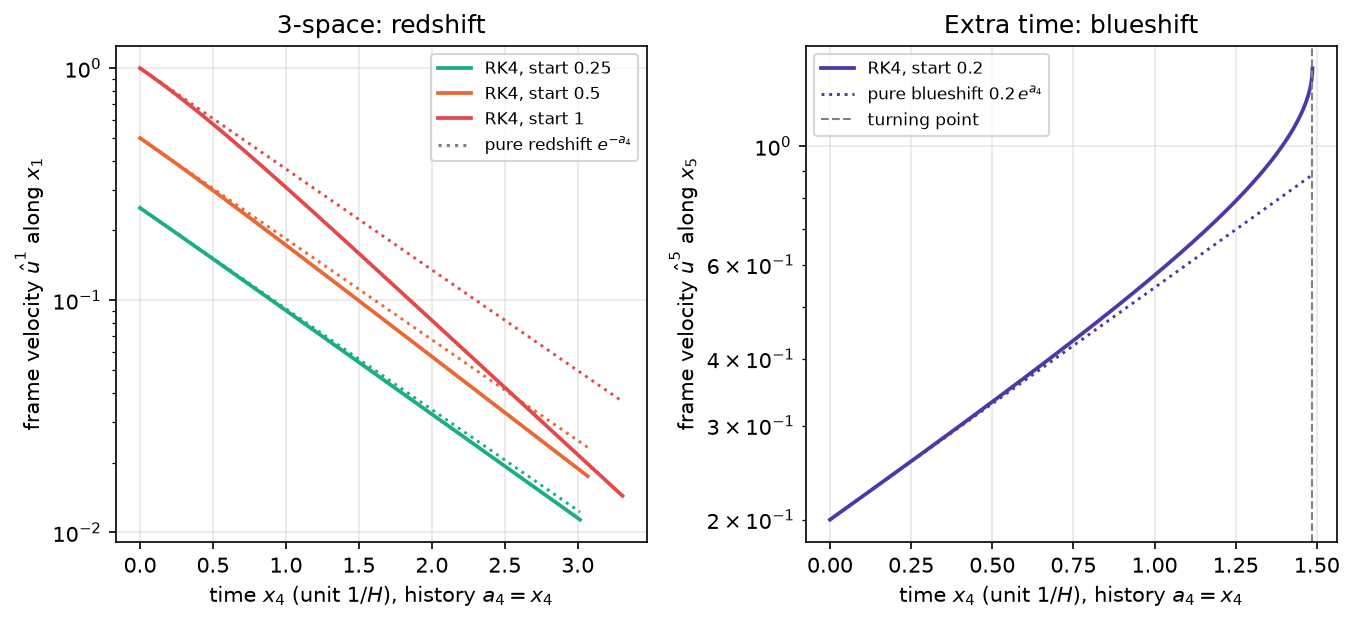

Figure 03d.1 saved as Revision/textbook/figures/03d_1_frame_velocities.png
PASS the extra-time frame velocity grows faster than the pure blueshift


In [12]:
BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
MAGENTA, GREEN, VIOLET, RED = "#e87ba4", "#008300", "#4a3aa7", "#e34948"
COLOURS = {0.25: AQUA, 0.5: ORANGE, 1.0: RED}  # one colour per 3-space particle
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.3))
fig.subplots_adjust(wspace=0.3)  # room for the label of the right vertical axis
for speed in SPEEDS:
    states, frame_rows = space_paths[speed][0], space_paths[speed][1]
    axes[0].plot(states[:, 3], frame_rows[:, 0], color=COLOURS[speed], lw=1.8,
                 label=f"RK4, start {speed:g}")
    axes[0].plot(states[:, 3], speed * np.exp(-A_value * H_value * states[:, 3]),
                 ":", color=COLOURS[speed], lw=1.4)
axes[0].plot([], [], ":", color="grey", label="pure redshift $e^{-a_4}$")
axes[0].set_yscale("log")
axes[0].set_xlabel("time $x_4$ (unit $1/H$), history $a_4 = x_4$")
axes[0].set_ylabel("frame velocity $\\hat u^1$ along $x_1$")
axes[0].set_title("3-space: redshift")
axes[0].legend(fontsize=8)
before = slice(0, n_turn)  # the states before the turning point
axes[1].plot(extra[before, 3], frame_t[before, 4], color=VIOLET, lw=1.8,
             label="RK4, start 0.2")
axes[1].plot(extra[before, 3], 0.2 * np.exp(A_value * H_value * extra[before, 3]),
             ":", color=VIOLET, lw=1.4, label="pure blueshift $0.2\\,e^{a_4}$")
axes[1].axvline(x4_max, color="grey", lw=1.0, ls="--", label="turning point")
axes[1].set_yscale("log")
axes[1].set_xlabel("time $x_4$ (unit $1/H$), history $a_4 = x_4$")
axes[1].set_ylabel("frame velocity $\\hat u^5$ along $x_5$")
axes[1].set_title("Extra time: blueshift")
axes[1].legend(fontsize=8, loc="upper left")
save_figure(fig, "frame_velocities",
            "Frame velocities of freely falling test particles in the author's metric "
            "along the deflating history $a_4 = x_4$ ($A = 1$, $H = 1$), all started "
            "at $x_4 = 0$, $y = -1$, computed with RK4 from the Christoffel symbols "
            "of the Revision record; horizontal axes the time $x_4$ in units of "
            "$1/H$, vertical axes the frame velocity (proper length per proper "
            "time, a pure number) on logarithmic scales. Left: three particles "
            "started along $x_1$ with $0.25$, $0.5$ and $1$; their frame velocity "
            "falls, a little faster than the pure redshift $e^{-a_4}$ (dotted), "
            "because they also rise towards the patch end. Right: a particle "
            "started along the extra time $x_5$ with $0.2$; its frame velocity "
            "grows, faster than the pure blueshift $0.2\\,e^{a_4}$ (dotted), until "
            f"its turning point at $x_4 = {x4_max:.3f}$ (dashed).")
check(frame_t[n_turn - 1, 4] > 0.2 * math.exp(extra[n_turn - 1, 3]),
      "the extra-time frame velocity grows faster than the pure blueshift")

The next cell draws the $x_4$ velocity $u^4$ (left) and the time $x_4$ itself
(right) against the proper time $\tau$ for all five particles. The particle at rest
keeps $u^4 = 1$. The particles in 3-space start with $u^4 = \sqrt{1 + (\hat u^1)^2}$
and slow down towards $1$ as their frame velocity is redshifted away. The particle
on the extra time starts with $u^4 = 0.98$, slows down to $0$ at its turning point
and continues with $u^4 < 0$: its $x_4$ reaches a largest value and then decreases.
With four time-like directions a time-like path need not keep advancing in $x_4$.

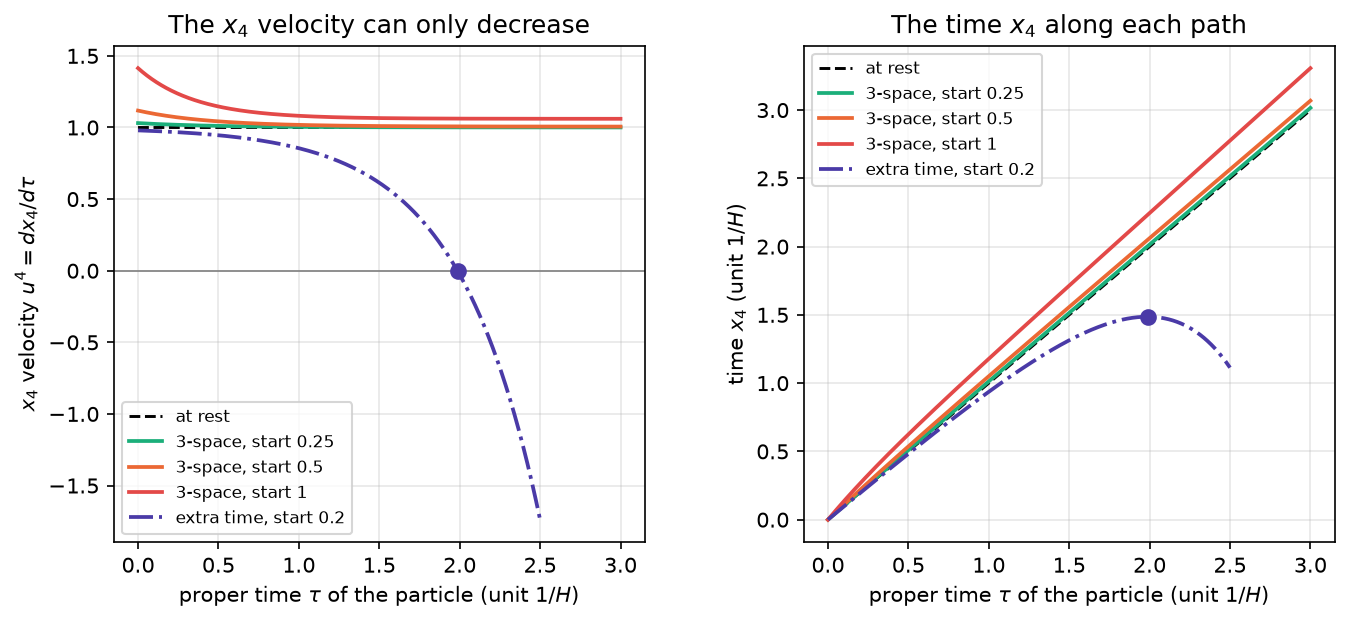

Figure 03d.2 saved as Revision/textbook/figures/03d_2_x4_velocity.png
PASS the particles in 3-space keep advancing in x4


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.3))
fig.subplots_adjust(wspace=0.3)
axes[0].plot(tau, rest[:, 11], color="black", lw=1.4, ls="--", label="at rest")
axes[1].plot(tau, rest[:, 3], color="black", lw=1.4, ls="--", label="at rest")
for speed in SPEEDS:
    states = space_paths[speed][0]
    axes[0].plot(tau, states[:, 11], color=COLOURS[speed], lw=1.8,
                 label=f"3-space, start {speed:g}")
    axes[1].plot(tau, states[:, 3], color=COLOURS[speed], lw=1.8,
                 label=f"3-space, start {speed:g}")
axes[0].plot(tau_t, extra[:, 11], color=VIOLET, lw=1.8, ls="-.",
             label="extra time, start 0.2")
axes[1].plot(tau_t, extra[:, 3], color=VIOLET, lw=1.8, ls="-.",
             label="extra time, start 0.2")
axes[0].axhline(0.0, color="grey", lw=0.8)
axes[0].plot([tau_t[n_turn]], [0.0], "o", color=VIOLET, ms=7)  # the turning point
axes[1].plot([tau_t[n_turn]], [x4_max], "o", color=VIOLET, ms=7)
axes[0].set_ylabel("$x_4$ velocity $u^4 = dx_4/d\\tau$")
axes[1].set_ylabel("time $x_4$ (unit $1/H$)")
axes[0].set_title("The $x_4$ velocity can only decrease")
axes[1].set_title("The time $x_4$ along each path")
for ax, place in zip(axes, ("lower left", "upper left")):  # legends off the lines
    ax.set_xlabel("proper time $\\tau$ of the particle (unit $1/H$)")
    ax.legend(fontsize=8, loc=place)
save_figure(fig, "x4_velocity",
            "The $x_4$ velocity $u^4 = dx_4/d\\tau$ (left) and the time $x_4$ "
            "(right) of five freely falling test particles against their own proper "
            "time $\\tau$ in units of $1/H$, along the deflating history $a_4 = x_4$, "
            "computed with RK4: a particle at rest (dashed, $u^4 = 1$ and "
            "$x_4 = \\tau$), three particles moving in 3-space (solid, started with "
            "frame velocities $0.25$, $0.5$, $1$), whose $u^4$ falls towards $1$ as "
            "their motion is redshifted, and a particle moving along an extra time "
            "(dash-dotted, started with $0.2$), whose $u^4$ falls through $0$ at its "
            f"turning point (dot, $\\tau = {tau_t[n_turn]:.2f}$), after which its "
            f"$x_4$, largest there ($x_4 = {x4_max:.3f}$), decreases.")
check(np.all(np.diff(space_paths[1.0][0][:, 3]) > 0),
      "the particles in 3-space keep advancing in x4")

The next cell shows the push along the hidden direction. Left: the height $y$ of
every particle against $\tau$; the particles in 3-space rise towards the patch end
$y = 0$, the particle on the extra time sinks towards the tip; the dashed line
marks the tip cut-off $y = -3$ of the Revision Kohn-Sham solver. Right: the
acceleration $d^2y/d\tau^2$ computed from the RK4 states by a numerical derivative
of $\hat u^8$ (`np.gradient`, central differences) as dots, and the exact law
$H(\sum_i (\hat u^i)^2 - \sum_j (\hat u^j)^2)$ of section 8 as lines, for the
fastest 3-space particle and the extra-time particle. The cell checks the agreement.

RESULT largest difference between the numerical acceleration and the law = 3.4e-06


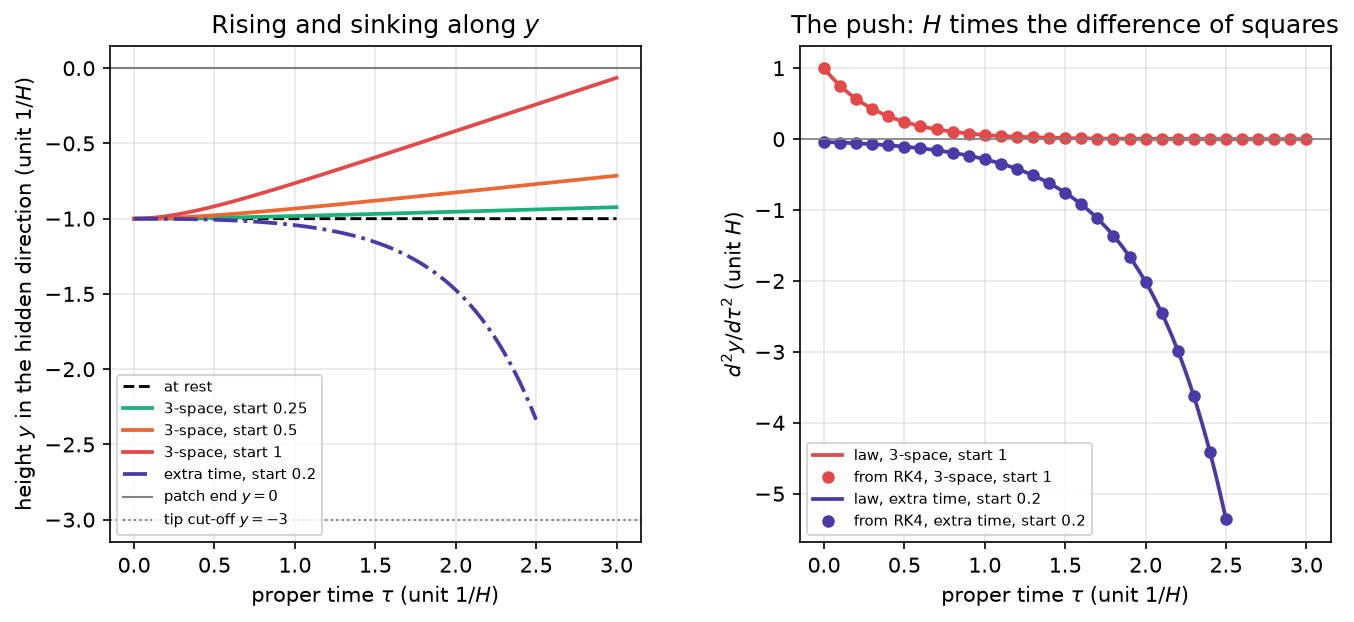

Figure 03d.3 saved as Revision/textbook/figures/03d_3_hidden_push.png
PASS the computed acceleration of y agrees with the exact push law


In [14]:
L_tip = physics["physics"]["L_tipCutoff"]  # the tip cut-off of the record, 3/H
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.3))
fig.subplots_adjust(wspace=0.3)
axes[0].plot(tau, np.full_like(tau, Y0), color="black", lw=1.4, ls="--",
             label="at rest")
for speed in SPEEDS:
    axes[0].plot(tau, space_paths[speed][2], color=COLOURS[speed], lw=1.8,
                 label=f"3-space, start {speed:g}")
axes[0].plot(tau_t, y_t, color=VIOLET, lw=1.8, ls="-.", label="extra time, start 0.2")
axes[0].axhline(0.0, color="grey", lw=1.0, label="patch end $y = 0$")
axes[0].axhline(-L_tip, color="grey", lw=1.0, ls=":", label="tip cut-off $y = -3$")
axes[0].set_xlabel("proper time $\\tau$ (unit $1/H$)")
axes[0].set_ylabel("height $y$ in the hidden direction (unit $1/H$)")
axes[0].set_title("Rising and sinking along $y$")
axes[0].legend(fontsize=7, loc="lower left")
largest_gap = 0.0
for (t_values, frame_rows), colour, label in (
        ((tau, space_paths[1.0][1]), RED, "3-space, start 1"),
        ((tau_t, frame_t), VIOLET, "extra time, start 0.2")):
    law = H_value * (np.sum(frame_rows[:, 0:3] ** 2, axis=1)
                     - np.sum(frame_rows[:, 4:7] ** 2, axis=1))
    numeric = np.gradient(frame_rows[:, 7], t_values)  # d(u8 hat)/dtau
    largest_gap = max(largest_gap, float(np.max(np.abs(numeric - law)[1:-1])))
    axes[1].plot(t_values, law, color=colour, lw=1.8, label=f"law, {label}")
    axes[1].plot(t_values[::100], numeric[::100], "o", color=colour, ms=5,
                 label=f"from RK4, {label}")
axes[1].axhline(0.0, color="grey", lw=0.8)
axes[1].set_xlabel("proper time $\\tau$ (unit $1/H$)")
axes[1].set_ylabel("$d^2y/d\\tau^2$ (unit $H$)")
axes[1].set_title("The push: $H$ times the difference of squares")
axes[1].legend(fontsize=7, loc="lower left")
report("largest difference between the numerical acceleration and the law",
       f"{largest_gap:.1e}")
save_figure(fig, "hidden_push",
            "The push along the hidden direction on freely falling test particles in "
            "the author's metric along the deflating history $a_4 = x_4$, computed "
            "with RK4; horizontal axes the proper time $\\tau$ in units of $1/H$. "
            "Left: the height $y$ (unit $1/H$) of the particle at rest (dashed, it "
            "stays at $y = -1$), of three particles moving in 3-space (solid), which "
            "rise towards the patch end $y = 0$, and of a particle moving along an "
            "extra time (dash-dotted), which sinks towards the tip; the dotted line "
            "is the tip cut-off $y = -3$ of the Revision Kohn-Sham solver. Right: "
            "the acceleration $d^2y/d\\tau^2$ (unit $H$) obtained from the computed "
            "states by a numerical derivative (dots) agrees with the exact law "
            "$H$ times the squared 3-space frame velocity minus the squared "
            "extra-time frame velocity (lines): positive for motion in 3-space, "
            "negative for motion along an extra time.")
check(largest_gap < 1e-4,
      "the computed acceleration of y agrees with the exact push law")

The next cell draws the quadratic form of section 9 as a map. For a particle that
moves only along $x_5$ and $y$, $(u^4)^2 = 1 - (\hat u^5)^2 + (\hat u^8)^2$. The map
shows this number over the plane of $\hat u^5$ (horizontal) and $\hat u^8$
(vertical): white where it is positive, grey where it is negative. On the grey side a
plane wave with these frame momenta (times $m$) would grow instead of oscillating,
according to the record's check `extra_time_growth_rates_unbounded`; a particle can
never be there, because $(u^4)^2 \ge 0$. The curve $(\hat u^5)^2 = 1 + (\hat u^8)^2$
separates the two regions. The path of the extra-time particle (violet) starts at
$(0.2, 0)$, moves right (blueshift) and down (it sinks), touches the curve at its
turning point and returns into the white region.

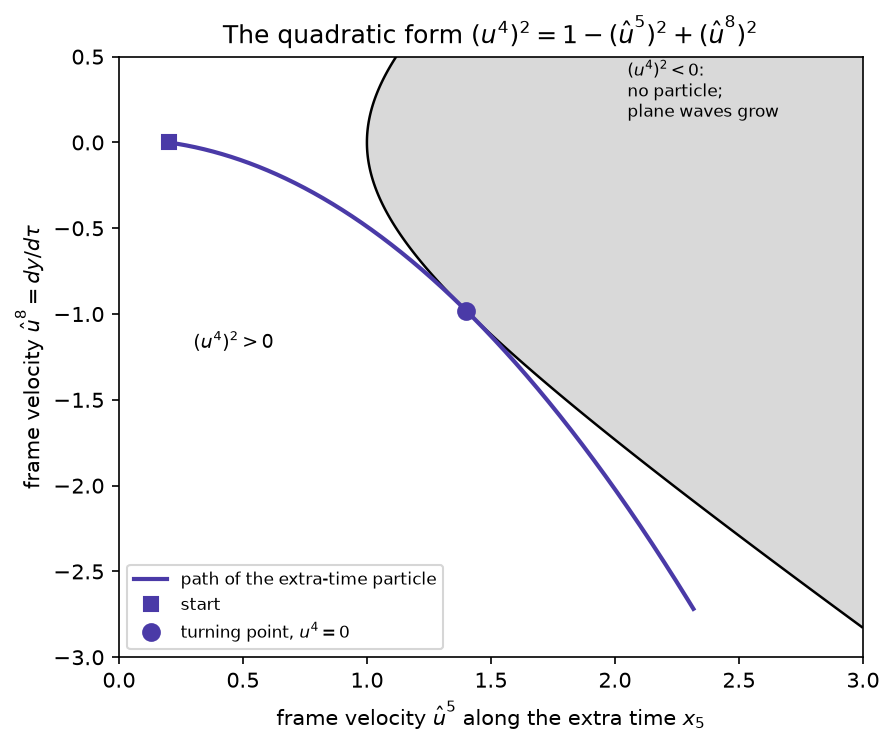

Figure 03d.4 saved as Revision/textbook/figures/03d_4_quadratic_form.png
PASS the path never enters the region where (u4)^2 < 0


In [15]:
grid5, grid8 = np.meshgrid(np.linspace(0.0, 3.0, 301), np.linspace(-3.0, 0.5, 351))
squared_u4 = 1 - grid5 ** 2 + grid8 ** 2  # (u^4)^2 over the plane
fig, ax = plt.subplots(figsize=(6.4, 5.2))
ax.contourf(grid5, grid8, squared_u4, levels=[-100.0, 0.0], colors=["#d9d9d9"])
ax.contour(grid5, grid8, squared_u4, levels=[0.0], colors="black", linewidths=1.2)
ax.plot(frame_t[:, 4], frame_t[:, 7], color=VIOLET, lw=2.0,
        label="path of the extra-time particle")
ax.plot([frame_t[0, 4]], [frame_t[0, 7]], "s", color=VIOLET, ms=7, label="start")
ax.plot([frame_t[n_turn, 4]], [frame_t[n_turn, 7]], "o", color=VIOLET, ms=8,
        label="turning point, $u^4 = 0$")
ax.text(2.05, 0.15, "$(u^4)^2 < 0$:\nno particle;\nplane waves grow", fontsize=8)
ax.text(0.3, -1.2, "$(u^4)^2 > 0$", fontsize=9)
ax.set_xlabel("frame velocity $\\hat u^5$ along the extra time $x_5$")
ax.set_ylabel("frame velocity $\\hat u^8 = dy/d\\tau$")
ax.set_title("The quadratic form $(u^4)^2 = 1 - (\\hat u^5)^2 + (\\hat u^8)^2$")
ax.grid(False)
ax.legend(fontsize=8, loc="lower left")
save_figure(fig, "quadratic_form",
            "The squared $x_4$ velocity $(u^4)^2 = 1 - (\\hat u^5)^2 + (\\hat u^8)^2$ "
            "of a free particle that moves along the extra time $x_5$ and the "
            "hidden coordinate $y$, as a map over its frame velocities $\\hat u^5$ "
            "(horizontal) and $\\hat u^8$ (vertical), both pure numbers: white where "
            "it is positive, grey where it is negative, the black curve "
            "$(\\hat u^5)^2 = 1 + (\\hat u^8)^2$ between them. Multiplied by $m^2$ it "
            "is the squared frequency of a plane wave in the Revision record "
            "(check extra_time_growth_rates_unbounded), which grows instead of "
            "oscillating in the grey region. The violet path of the extra-time "
            "particle of this notebook (RK4, history $a_4 = x_4$) starts at "
            "$(0.2, 0)$ (square), touches the curve at its turning point (dot) and "
            "returns into the white region.")
check(np.all(1 - frame_t[:, 4] ** 2 + frame_t[:, 7] ** 2 > -1e-6),
      "the path never enters the region where (u4)^2 < 0")

## 13. How accurate is the computation?

Two tests. First, the conserved quantities: the next cell draws, against $\tau$, how
far the computed $p_1$ (fastest 3-space particle), $p_5$ (extra-time particle) and
$g(u, u)$ (both) drift from their starting values, on a logarithmic axis. Second,
the order of RK4: it integrates both particles from $\tau = 0$ to $2$ with
$50, 100, 200, 400, 800, 1600$ steps and measures the largest difference of the end
states of two successive step sizes; for a method of order 4 each halving of the
step divides this difference by about $2^4 = 16$, so on logarithmic axes the points
lie on a line of slope 4.

  3-space, start 1: ratios of successive differences 17.1, 16.6, 16.3, 16.2
  extra time, start 0.2: ratios of successive differences 17.2, 16.7, 16.3, 16.2


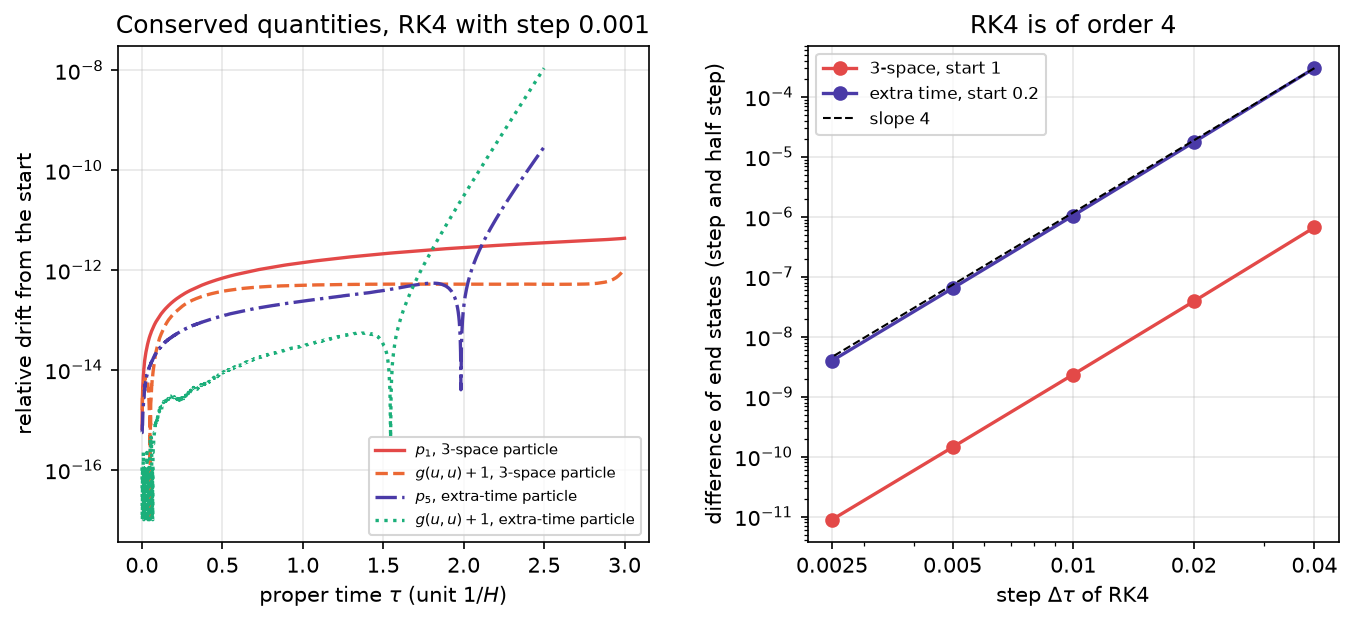

Figure 03d.5 saved as Revision/textbook/figures/03d_5_accuracy.png
PASS halving the RK4 step divides the error by 14 to 18: order 4


In [16]:
from matplotlib.ticker import NullFormatter  # an empty label for minor ticks

p1_fast = space_paths[1.0][4]  # p_1 along the fastest 3-space path
drift = {"$p_1$, 3-space particle": (tau, np.abs(p1_fast / p1_fast[0] - 1)),
         "$g(u,u) + 1$, 3-space particle": (tau, np.abs(space_paths[1.0][3] + 1)),
         "$p_5$, extra-time particle": (tau_t, np.abs(p5 / p5[0] - 1)),
         "$g(u,u) + 1$, extra-time particle": (tau_t, np.abs(lengths_t + 1))}
STEPS = (50, 100, 200, 400, 800, 1600)
differences = {}
for label, state0 in (("3-space, start 1", start(Y0, [1, 0, 0, 0, 0, 0, 0, 0])),
                      ("extra time, start 0.2", start(Y0, [0, 0, 0, 0, 0.2, 0, 0, 0]))):
    ends = [rk4_path(state0, 2.0, n)[1][-1] for n in STEPS]
    differences[label] = np.array([np.max(np.abs(ends[i] - ends[i + 1]))
                                   for i in range(len(STEPS) - 1)])
    ratios = differences[label][:-1] / differences[label][1:]
    say(f"  {label}: ratios of successive differences "
        + ", ".join(f"{r:.1f}" for r in ratios))
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.3))
fig.subplots_adjust(wspace=0.3)
for (label, (t_values, values)), colour, style in zip(
        drift.items(), (RED, ORANGE, VIOLET, AQUA), ("-", "--", "-.", ":")):
    axes[0].semilogy(t_values[1:], np.maximum(values[1:], 1e-17), color=colour,
                     ls=style, lw=1.6, label=label)
axes[0].set_xlabel("proper time $\\tau$ (unit $1/H$)")
axes[0].set_ylabel("relative drift from the start")
axes[0].set_title("Conserved quantities, RK4 with step $0.001$")
axes[0].legend(fontsize=7, loc="lower right")
dts = 2.0 / np.array(STEPS[:-1])  # the larger step of each pair
for (label, values), colour in zip(differences.items(), (RED, VIOLET)):
    axes[1].loglog(dts, values, "o-", color=colour, lw=1.6, label=label)
axes[1].loglog(dts, differences["extra time, start 0.2"][0] * (dts / dts[0]) ** 4,
               "--", color="black", lw=1.0, label="slope 4")
axes[1].set_xticks(dts, [f"{dt:g}" for dt in dts])  # the five steps as labels
axes[1].xaxis.set_minor_formatter(NullFormatter())  # no labels between them
axes[1].set_xlabel("step $\\Delta\\tau$ of RK4")
axes[1].set_ylabel("difference of end states (step and half step)")
axes[1].set_title("RK4 is of order 4")
axes[1].legend(fontsize=8)
save_figure(fig, "accuracy",
            "The accuracy of the RK4 computation of free fall in the author's metric "
            "along the deflating history $a_4 = x_4$. Left: the relative drift of "
            "the conserved momentum $p_1$ and of $g(u, u) + 1$ for the 3-space "
            "particle started with frame velocity $1$, and of $p_5$ and "
            "$g(u, u) + 1$ for the extra-time particle started with $0.2$, against "
            "the proper time $\\tau$ in units of $1/H$, logarithmic vertical axis; "
            "all stay far below $10^{-6}$ (the extra-time particle drifts more "
            "because its velocities grow). Right: the largest difference between "
            "the end states at $\\tau = 2$ computed with the step $\\Delta\\tau$ and "
            "with half of it, against $\\Delta\\tau$ on logarithmic axes, for the "
            "same two particles; the points follow the dashed line of slope 4: "
            "halving the step makes the error 16 times smaller.")
all_ratios = np.concatenate([d[1:-1] / d[2:] for d in differences.values()])
check(np.all((all_ratios > 14) & (all_ratios < 18)),
      "halving the RK4 step divides the error by 14 to 18: order 4")

## 14. The last check

The last cell checks that the five figure files exist in the folder
Revision/textbook/figures and prints the number of checks that passed.

In [17]:
figure_names = ["frame_velocities", "x4_velocity", "hidden_push", "quadratic_form",
                "accuracy"]
files = [output_file(f"{FIGURE_FOLDER}/03d_{n}_{name}.png")
         for n, name in enumerate(figure_names, 1)]
check(all(path.is_file() for path in files), "all five figure files exist")
all_checks_passed()

PASS all five figure files exist
ALL 23 CHECKS PASSED (notebook 03d)


## 15. What this notebook showed

- PROVED (exact, sympy, for every function $a_4(x_4)$, with the Christoffel symbols
  of the Revision record): in free fall the six momenta $p_a = g_{aa} u^a$ of
  $x_1, x_2, x_3, x_5, x_6, x_7$ and the squared length $g(u, u)$ are conserved; the
  frame velocity in 3-space is $p_1 e^{-Hy - a_4}$ (the momentum weight $\kappa$ of
  the Revision Kohn-Sham record) and along an extra time $-p_5 e^{a_4 - Hy}$;
  $d^2y/d\tau^2 = H(\sum_i (\hat u^i)^2 - \sum_j (\hat u^j)^2)$;
  $du^4/d\tau = -a_4'(\sum_i (\hat u^i)^2 + \sum_j (\hat u^j)^2)$; and
  $(u^4)^2 = 1 + \sum_i (\hat u^i)^2 - \sum_j (\hat u^j)^2 + (\hat u^8)^2$, which,
  times $m^2$, is the quadratic form of the plane-wave check of the Revision scope
  report.
- So along a deflating history ($a_4$ increasing) motion in 3-space is redshifted
  like $e^{-a_4}$ and motion along an extra time is blueshifted like $e^{a_4}$;
  3-space motion pushes a particle towards the patch end, extra-time motion towards
  the tip; the $x_4$ velocity can only decrease.
- COMPUTED (RK4 with the step $0.001$, along the prescribed history $a_4 = x_4$,
  $H = 1$, from $y = -1$): a particle at rest stays at rest with $x_4 = \tau$; three
  particles moving in 3-space slow down and rise towards the patch end; a particle
  started along the extra time $x_5$ with frame velocity $0.2$ reaches a largest
  $x_4$ (the RESULT lines above) and then moves back in $x_4$; every exact law holds
  on the computed paths, and RK4 shows its order 4.
- A particle without extra-time momentum has $(u^4)^2 \ge 1$ and never turns
  (PROVED); the Revision Kohn-Sham work keeps only states without extra-time
  momenta (its good sector).
- ASSUMED: the history $a_4 = AHx_4$ (a prescribed background); test particles
  that do not change the metric. NOT computed here: whether the waves of the fields
  follow these paths in the curved metric.